# VC-Genome Full Pipeline: All 520 Images

Processes all 520 images from `image_compiled_phrases.csv` using Claude API-generated extractions.

**Stage 1:** Load API extractions from `vc_genome_output/llm_extractions_api.json`  
**Stage 2:** Canonicalize against ontology  
**Stage 3:** Build scene graphs, compute metrics, save SVGs (no inline display)  

All outputs saved to `vc_genome_output_full/`.

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os, sys, json, graphviz
from pathlib import Path
from collections import defaultdict, Counter
from IPython.display import display

pd.set_option('display.max_colwidth', 120)

# Graphviz setup for Windows
os.environ['PATH'] = r'C:\Program Files (x86)\Graphviz\bin;' + os.environ.get('PATH', '')
os.environ['PANGOCAIRO_BACKEND'] = 'fontconfig'

# Output directories
OUT_DIR   = Path('vc_genome_output_full')
GRAPH_DIR = OUT_DIR / 'graphs'
OUT_DIR.mkdir(exist_ok=True)
GRAPH_DIR.mkdir(exist_ok=True)
print(f'Output dir: {OUT_DIR.resolve()}')

Output dir: D:\Coding\Copilot\comment_post_processing\vc_genome_output_full


## Load Data

In [2]:
compiled     = pd.read_csv('phrase_reduction_v2/image_compiled_phrases.csv')
subtopics_df = pd.read_csv('phrase_reduction_v2/phrase_shortlist.csv')

print(f'Total images in dataset: {len(compiled)}')
print(f'VisTypes: {sorted(compiled["VisType"].unique())}')
print(f'VC range: {compiled["NormalizedVC"].min():.2f} – {compiled["NormalizedVC"].max():.2f}')

Total images in dataset: 520
VisTypes: ['Area', 'Area and Text', 'Bar', 'Bar and point', 'Cont.-ColorPatn', 'Glyph', 'Grid', 'Line', 'Node-link', 'Point', 'Schematic', 'Table', 'Text']
VC range: 0.15 – 0.95


## Stage 1: Load API Extractions

In [3]:
EXTRACTIONS_FILE = Path('vc_genome_output/llm_extractions_api.json')

with open(EXTRACTIONS_FILE, 'r', encoding='utf-8') as f:
    stage1_extractions = json.load(f)

print(f'Extractions available: {len(stage1_extractions)} / {len(compiled)}')

# Only process images that have extractions
images_df = compiled[compiled['imageName'].isin(stage1_extractions)].copy().reset_index(drop=True)
missing   = compiled[~compiled['imageName'].isin(stage1_extractions)]['imageName'].tolist()

print(f'Images to process:      {len(images_df)}')
if missing:
    print(f'Missing extractions ({len(missing)}): run _extract_stage1_api.py to complete.')

Extractions available: 520 / 520
Images to process:      520


## Stage 2: Canonicalization

In [4]:
OBJECT_SYNSETS = {
    'bar': 'mark.bar', 'dot': 'mark.point', 'point': 'mark.point',
    'shape': 'mark.shape', 'line': 'mark.line', 'vertical_line': 'mark.line',
    'color_segment': 'mark.color_segment', 'color': 'property.color',
    'box': 'structure.panel', 'layout': 'structure.layout',
    'pattern': 'structure.pattern', 'data_pattern': 'structure.pattern',
    'connection': 'structure.link', 'node': 'mark.node', 'link': 'structure.link',
    'title': 'text.title', 'description': 'text.description',
    'axis_label': 'text.axis_label', 'label': 'text.label', 'text': 'text.label',
    'legend': 'furniture.legend', 'color_code': 'furniture.legend',
    'visualization': 'whole.visualization', 'chart': 'whole.visualization',
    'graph': 'whole.visualization', 'image': 'whole.visualization',
    'data': 'content.data', 'information': 'content.data',
    'knowledge': 'content.domain', 'concept': 'content.domain',
    'element': 'mark.element', 'object': 'mark.element',
    'detail': 'content.detail', 'number': 'content.number',
    'area': 'mark.area', 'region': 'structure.region',
    'grid': 'structure.grid', 'cell': 'structure.cell',
    'symbol': 'mark.symbol', 'icon': 'mark.symbol',
    'annotation': 'text.annotation', 'map': 'whole.visualization',
    'area_marks': 'mark.area', 'area_shape': 'mark.area',
    'chart_structure': 'whole.visualization', 'color_shading': 'property.color',
}

PREDICATE_CANON = {
    'describes': 'describes', 'labels': 'describes', 'clarifies': 'clarifies',
    'encodes_via': 'encodes_via', 'fills': 'fills',
    'overlaps_with': 'overlaps_with', 'varies_across': 'varies_across',
    'connects': 'connects', 'fails_to_explain': 'fails_to_explain',
    'obscures': 'obscures', 'scattered_across': 'distributed_across',
    'mixed_with': 'co_occurs_with', 'lacks_story': 'lacks_meaning_for',
    'requires_expertise': 'requires_expertise_for', 'overwhelms': 'overwhelms',
    'distinguish': 'distinguishes', 'understand': 'interpreted_via',
    'interpret': 'interpreted_via', 'read': 'interpreted_via',
    'compare': 'compared_with', 'identify': 'identifies',
    'represent': 'represents', 'show': 'represents',
    'display': 'represents', 'indicate': 'indicates',
    'overlap': 'overlaps_with', 'clutter': 'clutters',
    'confuse': 'confuses', 'simplify': 'simplifies',
    'facilitates_reading_of': 'facilitates_reading_of',
    'clarifies_meaning_of': 'clarifies_meaning_of',
    'structures': 'structures', 'missing_from': 'missing_from',
    'increases_ambiguity_of': 'increases_ambiguity_of',
    'fails_to_decode': 'fails_to_decode', 'fails_to_clarify': 'fails_to_clarify',
    'suggests_uncertain': 'suggests_uncertain', 'increases': 'increases',
}


def canonicalize(extraction):
    canon  = {'objects': [], 'attributes': [], 'relationships': []}
    id_map = {}
    for obj in extraction['objects']:
        synset = OBJECT_SYNSETS.get(obj['name'], f"unknown.{obj['name']}")
        id_map[obj['id']] = synset
        canon['objects'].append({
            'id': obj['id'], 'name': obj['name'],
            'synset': synset, 'region': obj['region']
        })
    for attr in extraction['attributes']:
        oid = attr['object_id']
        if oid not in id_map:
            continue
        canon['attributes'].append({
            'object_id': oid, 'object_synset': id_map[oid],
            'attr': attr['attr'], 'sentiment': attr['sentiment'],
            'subtopic': attr['subtopic'],
        })
    for rel in extraction['relationships']:
        if rel['subj'] not in id_map or rel['obj'] not in id_map:
            continue
        canon['relationships'].append({
            'subject_synset': id_map[rel['subj']],
            'predicate': PREDICATE_CANON.get(rel['pred'], rel['pred']),
            'object_synset': id_map[rel['obj']],
            'sentiment': rel['sentiment'],
            'subtopic': rel['subtopic'],
        })
    return canon


stage2_canonical = {img: canonicalize(ext) for img, ext in stage1_extractions.items()}
print(f'Canonicalized {len(stage2_canonical)} images')

Canonicalized 520 images


## Stage 3: Build Scene Graphs, Compute Metrics & Save SVGs

In [6]:
SUBTOPIC_TO_TOPIC = dict(zip(subtopics_df['SubTopic'], subtopics_df['Topic']))
COLOR_OBJECT    = '#b8e6b8'
COLOR_ATTRIBUTE = '#c7b8e6'
COLOR_RELATION  = '#f5b8b8'
UNDIRECTED_PREDS = {'co_occurs_with', 'overlaps_with'}


def build_scene_graph(canon_data, image_name):
    G = nx.DiGraph()
    G.graph['image'] = image_name
    for obj in canon_data['objects']:
        G.add_node(obj['synset'], label=obj['name'], synset=obj['synset'],
                   region=obj['region'], node_type='object',
                   attributes=[], sentiments=[])
    for attr in canon_data['attributes']:
        nid = attr['object_synset']
        if nid in G:
            G.nodes[nid]['attributes'].append(attr['attr'])
            G.nodes[nid]['sentiments'].append(attr['sentiment'])
    for rel in canon_data['relationships']:
        G.add_edge(rel['subject_synset'], rel['object_synset'],
                   predicate=rel['predicate'], sentiment=rel['sentiment'],
                   subtopic=rel['subtopic'],
                   topic=SUBTOPIC_TO_TOPIC.get(rel['subtopic'], 'Unknown'))
    return G


def compute_graph_metrics(G):
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    all_sents  = [s for n in G.nodes for s in G.nodes[n].get('sentiments', [])]
    all_sents += [G.edges[e]['sentiment'] for e in G.edges]
    n_attrs = sum(len(G.nodes[n].get('attributes', [])) for n in G.nodes)
    n_pos   = sum(1 for s in all_sents if s == '+')
    n_neg   = sum(1 for s in all_sents if s == '-')
    subtopics_hit = set(G.edges[e].get('subtopic', '') for e in G.edges)
    regions = set(G.nodes[n].get('region', '') for n in G.nodes)
    max_edges = n_nodes * (n_nodes - 1) if n_nodes > 1 else 1
    return {
        'nodes': n_nodes, 'edges': n_edges, 'attributes': n_attrs,
        'attr_density':    round(n_attrs / max(n_nodes, 1), 2),
        'edge_density':    round(n_edges / max_edges, 3),
        'positive_count':  n_pos, 'negative_count': n_neg,
        'positive_ratio':  round(n_pos / max(len(all_sents), 1), 2),
        'subtopics_covered': len(subtopics_hit),
        'regions_used':    len(regions),
    }


def build_vg_graphviz(canon_data, image_name, vc, vistype):
    dot = graphviz.Digraph(
        name=image_name, format='svg',
        graph_attr={'rankdir': 'LR', 'fontsize': '10', 'fontname': 'Arial',
                    'nodesep': '0.4', 'ranksep': '0.6', 'splines': 'true', 'bgcolor': 'white'},
        node_attr={'fontname': 'Arial', 'fontsize': '10', 'shape': 'box',
                   'style': 'rounded,filled', 'penwidth': '1.2'},
        edge_attr={'fontname': 'Arial', 'fontsize': '9', 'color': '#888888'},
    )
    attrs_by_obj = defaultdict(list)
    for i, attr in enumerate(canon_data['attributes']):
        sent  = '(+)' if attr['sentiment'] == '+' else '(\u2212)'
        label = f"{sent} {attr['attr'].replace('_', ' ')[:30]}"
        attrs_by_obj[attr['object_synset']].append((f'attr_{i}', label))

    for obj in canon_data['objects']:
        dot.node(obj['synset'], label=obj['name'].replace('_', ' '),
                 fillcolor=COLOR_OBJECT, color='#2c3e50', fontcolor='#1a1a1a', penwidth='1.8')
    for obj in canon_data['objects']:
        for attr_id, attr_label in attrs_by_obj.get(obj['synset'], []):
            dot.node(attr_id, label=attr_label, fillcolor=COLOR_ATTRIBUTE,
                     color='#7f8c8d', fontcolor='#1a1a1a')
            dot.edge(obj['synset'], attr_id, color='#aaaaaa', arrowsize='0.7')

    for ri, rel in enumerate(canon_data['relationships']):
        pred_id = f'rel_{ri}'
        dot.node(pred_id, label=rel['predicate'].replace('_', ' '),
                 fillcolor=COLOR_RELATION, color='#d46a6a', fontcolor='#8b0000')
        dot.edge(rel['subject_synset'], pred_id, color='#d46a6a', penwidth='1.5', arrowsize='0.8')
        if rel['predicate'] in UNDIRECTED_PREDS:
            dot.edge(pred_id, rel['object_synset'], color='#d46a6a',
                     penwidth='1.5', style='dashed', arrowhead='none')
        else:
            dot.edge(pred_id, rel['object_synset'], color='#d46a6a', penwidth='1.5', arrowsize='0.8')

    title_html = f'''<
    <TABLE BORDER="0" CELLBORDER="0" CELLSPACING="2" CELLPADDING="2">
    <TR><TD COLSPAN="8" ALIGN="CENTER"><B><FONT POINT-SIZE="14">{image_name}</FONT></B></TD></TR>
    <TR><TD COLSPAN="8" ALIGN="CENTER"><FONT POINT-SIZE="11">{vistype}  |  VC = {vc:.2f}</FONT></TD></TR>
    <TR>
      <TD BGCOLOR="#b8e6b8" BORDER="1" STYLE="rounded" WIDTH="20"> </TD><TD>Object</TD>
      <TD BGCOLOR="#c7b8e6" BORDER="1" STYLE="rounded" WIDTH="20"> </TD><TD>Attribute</TD>
      <TD BGCOLOR="#f5b8b8" BORDER="1" STYLE="rounded" WIDTH="20"> </TD><TD>Relationship</TD>
      <TD><B>(+)</B> increases complexity</TD>
      <TD><B>(\u2212)</B> decreases complexity</TD>
    </TR>
    </TABLE>>'''
    dot.attr(label=title_html, labelloc='t', labeljust='c')
    return dot


# Process all images
metrics_rows = []
n_total = len(images_df)

for i, (_, row) in enumerate(images_df.iterrows(), 1):
    # if i==3: break  # TEMP: only do first 3 for testing
    img   = row['imageName']
    canon = stage2_canonical[img]
    G     = build_scene_graph(canon, img)
    m     = compute_graph_metrics(G)
    metrics_rows.append({'imageName': img, 'VisType': row['VisType'],
                         'NormalizedVC': row['NormalizedVC'], **m})

    dot = build_vg_graphviz(canon, img, row['NormalizedVC'], row['VisType'])
    _stderr = sys.stderr
    sys.stderr = open(os.devnull, 'w')
    try:
        svg_data = dot.pipe(format='svg')
    finally:
        sys.stderr.close()
        sys.stderr = _stderr

    safe_name = img.replace('(', '').replace(')', '').replace('.png', '')
    (GRAPH_DIR / f'{safe_name}.svg').write_bytes(svg_data)

    if i % 50 == 0 or i == n_total:
        print(f'  [{i}/{n_total}] last saved: {img}')

# Save metrics CSV
metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(OUT_DIR / 'graph_metrics.csv', index=False)
print(f'\nSaved {len(metrics_df)} rows to {OUT_DIR}/graph_metrics.csv')
print(f'Saved {len(metrics_rows)} SVGs to {GRAPH_DIR}/')

  [50/520] last saved: InfoVisJ.1634.1.png
  [100/520] last saved: VASTC.72.13.png
  [150/520] last saved: VisC.175.1(3).png
  [200/520] last saved: SciVisJ.980.9.png
  [250/520] last saved: VASTC.41.5.png
  [300/520] last saved: InfoVisC.103.9.png
  [350/520] last saved: VisC.11.12(2).png
  [400/520] last saved: VASTJ.1.10.png
  [450/520] last saved: VisC.501.7(2).png
  [500/520] last saved: VASTJ.1763.8(2).png
  [520/520] last saved: InfoVisJ.2546.10.png

Saved 520 rows to vc_genome_output_full/graph_metrics.csv
Saved 520 SVGs to vc_genome_output_full\graphs/


## Metrics Summary

In [7]:
display(metrics_df.describe().round(3))

,NormalizedVC,nodes,edges,attributes,attr_density,edge_density,positive_count,negative_count,positive_ratio,subtopics_covered,regions_used
count,520.000,520.000,520.000,520.000,520.000,520.000,520.000,520.000,520.000,520.000,520.000
mean,0.595,5.062,3.912,5.710,1.136,0.199,7.529,2.092,0.766,3.823,3.248
std,0.150,0.750,0.716,0.899,0.150,0.056,3.856,3.255,0.369,0.747,0.907
min,0.150,3.000,2.000,3.000,0.830,0.095,0.000,0.000,0.000,2.000,2.000
25%,0.500,5.000,3.000,5.000,1.000,0.167,6.000,0.000,0.635,3.000,3.000
50%,0.590,5.000,4.000,6.000,1.170,0.200,9.000,0.000,1.000,4.000,3.000
75%,0.710,5.000,4.000,6.000,1.200,0.200,10.000,3.250,1.000,4.000,4.000
max,0.950,7.000,5.000,8.000,1.750,0.500,13.000,12.000,1.000,5.000,6.000


In [9]:
# display(metrics_df.style.format({
#     'NormalizedVC': '{:.2f}', 'attr_density': '{:.2f}',
#     'edge_density': '{:.3f}', 'positive_ratio': '{:.0%}',
# }).background_gradient(subset=['NormalizedVC', 'positive_ratio', 'subtopics_covered'], cmap='YlOrRd'))

## Subtopic Coverage Heatmap (by VisType average)

Rather than plotting all 520 columns, aggregate by VisType mean for readability.

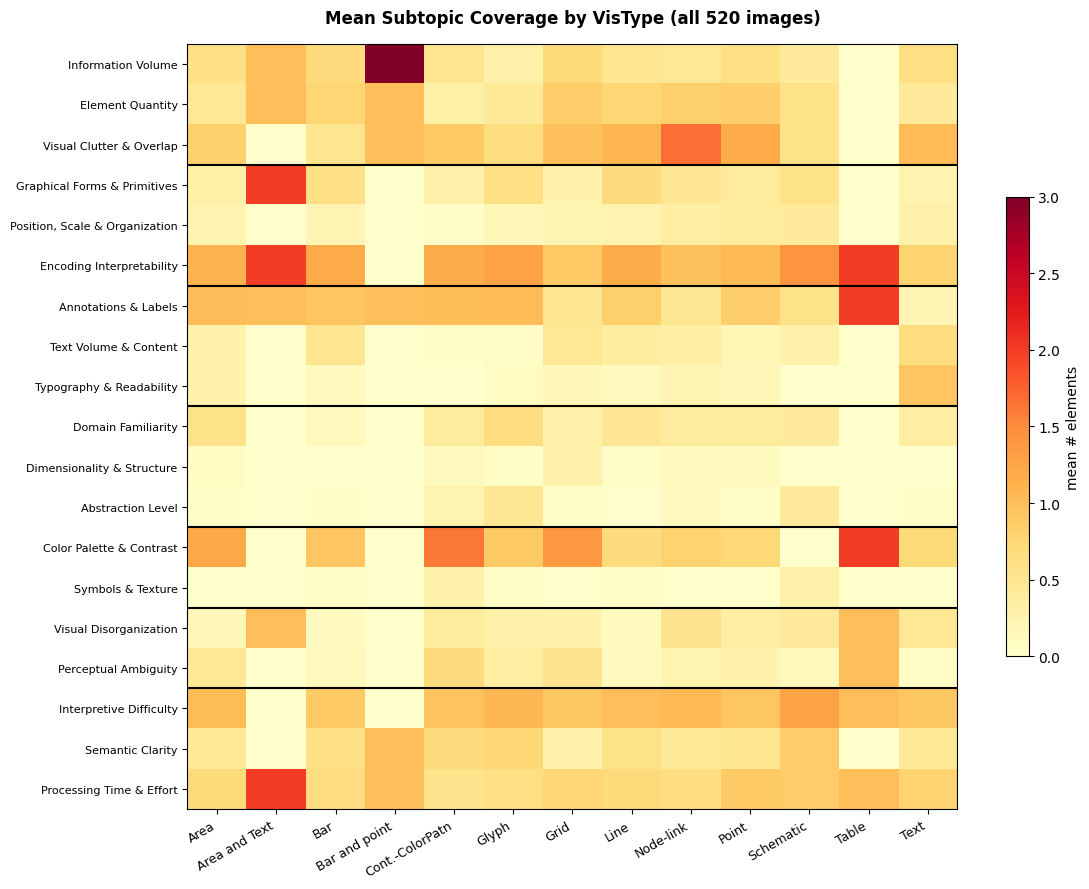

Saved heatmap to vc_genome_output_full/subtopic_coverage_heatmap_by_vistype.png


In [10]:
all_subtopics = subtopics_df['SubTopic'].tolist()

# Per-image coverage counts
coverage_rows = []
for img, canon in stage2_canonical.items():
    hit = Counter()
    for a in canon['attributes']:
        hit[a['subtopic']] += 1
    for r in canon['relationships']:
        hit[r['subtopic']] += 1
    row_data = {'imageName': img}
    row_data.update({st: hit.get(st, 0) for st in all_subtopics})
    coverage_rows.append(row_data)

cov_df = pd.DataFrame(coverage_rows).set_index('imageName')
cov_df.to_csv(OUT_DIR / 'subtopic_coverage.csv')

# Merge with VisType and aggregate
cov_merged = cov_df.merge(compiled[['imageName', 'VisType']].set_index('imageName'),
                           left_index=True, right_index=True)
vt_means = cov_merged.groupby('VisType')[all_subtopics].mean()

fig, ax = plt.subplots(figsize=(max(10, len(vt_means) * 0.9), 9))
im = ax.imshow(vt_means.T.values, cmap='YlOrRd', aspect='auto', interpolation='nearest')

ax.set_xticks(range(len(vt_means)))
ax.set_xticklabels(vt_means.index, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(all_subtopics)))
ax.set_yticklabels(all_subtopics, fontsize=8)

prev_topic = None
for i, st in enumerate(all_subtopics):
    topic = subtopics_df.loc[subtopics_df['SubTopic'] == st, 'Topic'].values[0]
    if prev_topic and topic != prev_topic:
        ax.axhline(y=i - 0.5, color='black', linewidth=1.5)
    prev_topic = topic

ax.set_title('Mean Subtopic Coverage by VisType (all 520 images)',
             fontsize=12, fontweight='bold', pad=15)
plt.colorbar(im, ax=ax, label='mean # elements', shrink=0.6)
plt.tight_layout()
fig.savefig(OUT_DIR / 'subtopic_coverage_heatmap_by_vistype.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved heatmap to {OUT_DIR}/subtopic_coverage_heatmap_by_vistype.png')

## Output Summary

In [11]:
print('=== VC-Genome Full Pipeline Output ===')
print(f'Images processed: {len(metrics_df)}')
print(f'VisTypes covered: {metrics_df["VisType"].nunique()}')
svg_count = len(list(GRAPH_DIR.glob('*.svg')))
print(f'SVGs saved:       {svg_count}')
print(f'\nFiles in {OUT_DIR}/:')
for f in sorted(OUT_DIR.glob('*')):
    if f.is_file():
        print(f'  {f.name:45s} {f.stat().st_size:>9,d} bytes')

=== VC-Genome Full Pipeline Output ===
Images processed: 520
VisTypes covered: 13
SVGs saved:       520

Files in vc_genome_output_full/:
  graph_metrics.csv                                30,657 bytes
  subtopic_coverage.csv                            30,228 bytes
  subtopic_coverage_heatmap_by_vistype.png        118,622 bytes
